# Where the model gets it wrong

The model is frozen (notebook 09) and gets 61.1% of validation maps right. This asks the
more useful question: **which maps does it miss, and is there a pattern?**

Nothing here changes the model. The test halves are still untouched.

### What it found

| | |
|---|---|
| Best on matches **between regions** | 72.8% vs 59.5%, and not just because those come later in the season |
| Best on **decider maps** | 68.9%, where nobody chose the map |
| Worst at **Pacific Kickoff** | 50% — a coin flip — where the one-sentence rule got 67% |
| Its mistakes are **not just close games** | it gets thumpings wrong too |
| It is **not misjudging particular teams** | those are variance, not bias — though it under-rates the best teams |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from dataset import build_map_table, season_folds, split_season
from features import build_features, feature_columns
from form import load_player_maps, player_form
from model import FINAL_COLUMNS, make_final_model

HALF_LIFE = 5

maps = build_map_table()
learn, test = split_season(maps)
X_agents, y = build_features(learn, feature_columns(maps))
form = player_form(learn, half_life=HALF_LIFE)
X = pd.concat([X_agents[["map_picked_by_a"]], form], axis=1)[FINAL_COLUMNS].astype(float)

# Every validation prediction: each fold's model judging maps it never saw.
chances = []
for learn_rows, check_rows in season_folds(learn):
    model = clone(make_final_model()).fit(X.loc[learn_rows], y.loc[learn_rows])
    chances.append(pd.Series(model.predict_proba(X.loc[check_rows])[:, 1], index=check_rows))
chance_a = pd.concat(chances)

checked = learn.loc[chance_a.index].copy()
checked["chance_a"] = chance_a
checked["right"] = (checked["chance_a"] >= 0.5).astype(int) == checked["team_a_won"]
checked["picker_right"] = (
    checked["map_picked_by"].map({"team_a": 1, "team_b": 0}).fillna(1) == checked["team_a_won"]
)

print(f"{len(checked)} validation maps, {checked['right'].mean():.1%} right overall")

629 validation maps, 61.2% right overall


## 1. How much of any pattern is just noise?

Slicing 629 maps into groups makes small groups, and small groups bounce around. Before
reading anything into a difference, it helps to know how big a difference chance alone
produces. Every table below carries a `± ` column: the amount a group of that size could
drift on luck alone. **Differences smaller than that are not findings.**

In [2]:
def noise(n):
    """How far a group of n maps can drift by chance alone, in percentage points."""
    return 100 * 1.96 * np.sqrt(0.25 / n)


def breakdown(by, label=None):
    """Model accuracy and the picker rule's, side by side, for each group."""
    table = checked.groupby(by, observed=True).agg(
        maps=("right", "size"),
        model=("right", lambda s: round(s.mean() * 100, 1)),
        picker_rule=("picker_right", lambda s: round(s.mean() * 100, 1)),
    )
    table["±"] = table["maps"].map(lambda n: round(noise(n), 1))
    if label:
        table.index.name = label
    return table


for n in (50, 100, 250, 629):
    print(f"  a group of {n:>3} maps can drift ±{noise(n):.1f} points on luck alone")

  a group of  50 maps can drift ±13.9 points on luck alone
  a group of 100 maps can drift ±9.8 points on luck alone
  a group of 250 maps can drift ±6.2 points on luck alone
  a group of 629 maps can drift ±3.9 points on luck alone


## 2. By tournament

In [3]:
breakdown("event").sort_values("model")

,maps,model,picker_rule,±
event,,,,
VCT 2025 Pacific Kickoff,46,50.0,67.4,14.4
VCT 2025 Pacific Stage 1,107,58.9,57.0,9.5
VCT 2025 Americas Stage 1,104,59.6,58.7,9.6
VCT 2025 China Stage 1,105,60.0,48.6,9.6
VCT 2025 EMEA Stage 1,104,60.6,52.9,9.6
Valorant Masters Bangkok 2025,42,61.9,61.9,15.1
VCT 2025 EMEA Kickoff,26,65.4,46.2,19.2
Valorant Masters Toronto 2025,59,71.2,55.9,12.8
VCT 2025 Americas Kickoff,32,71.9,53.1,17.3


The worst is **Pacific Kickoff at 50%** — a coin flip — where the one-sentence picker rule
got 67.4%. Kickoff is the first event of the year: nobody has a record yet, so the model is
working from almost nothing. The best are the two international events and the later
Kickoffs, though several of these groups are small enough that the ± column matters.

## 3. By how much history the players had

The obvious suspect, following on from notebook 09.

In [4]:
# How many rated maps sat behind the less-known of the two sides, going into each map.
players = load_player_maps(learn).sort_values(["played_at", "match_id"])
seen, history = {}, {}
for (_, match_id), match in players.groupby(["played_at", "match_id"], sort=True):
    for team in (match.iloc[0]["team_a"], match.iloc[0]["team_b"]):
        names = match[match["Team"] == team]["Player"].unique()
        side = np.mean([seen.get(name, 0) for name in names])
        history[match_id] = min(history.get(match_id, np.inf), side)
    for _, performance in match.iterrows():
        if pd.notna(performance["Rating"]):
            seen[performance["Player"]] = seen.get(performance["Player"], 0) + 1

checked["history"] = checked["match_id"].map(history)
checked["history_band"] = pd.cut(checked["history"], [-1, 5, 10, 20, 1000],
                                 labels=["under 5 maps", "5-10", "10-20", "20+"])

breakdown("history_band", "rated maps behind the less-known side")

,maps,model,picker_rule,±
rated maps behind the less-known side,,,,
under 5 maps,150,61.3,55.3,8.0
5-10,155,58.1,56.1,7.9
10-20,200,60.5,53.5,6.9
20+,124,66.1,58.9,8.8


Only the top group stands out, and its ±8.8 range overlaps the others, so read this
carefully. What it does **not** show is the steady climb notebook 09 found on the model as
it stood *before* the combat-score repair, which went 58.0 / 58.1 / 59.5 / 64.5.

That difference is the repair doing its job. The thin-history maps were mostly the Chinese
matches with no rating recorded, and those are exactly the ones it fixed — so the bottom of
the ladder came up and the slope flattened. If you quote the old 58-to-64.5 climb anywhere,
say that it describes the earlier model.

What survives is the top end: once both sides have 20+ rated maps behind them the model is
around 66% against roughly 60% elsewhere, and the picker rule does not improve the same way.
So history still helps — it is just no longer the whole story.

## 4. Matches between regions

The four leagues (Americas, EMEA, Pacific, China) play separately most of the year and only
meet at Masters and Champions. Each team's home league is taken from the league events it
appears in.

In [5]:
league_maps = checked[checked["event"].str.startswith("VCT")]
seen_in = {}
for side in ("team_a", "team_b"):
    for team, event in zip(league_maps[side], league_maps["event"]):
        seen_in.setdefault(team, []).append(event.split()[2])  # "VCT 2025 Americas Stage 1"
home_league = {team: pd.Series(regions).mode()[0] for team, regions in seen_in.items()}

checked["across_regions"] = (
    checked["team_a"].map(home_league) != checked["team_b"].map(home_league)
).map({True: "different leagues", False: "same league"})

breakdown("across_regions", "the two teams are from")

,maps,model,picker_rule,±
the two teams are from,,,,
different leagues,95,69.5,58.9,10.1
same league,534,59.7,55.1,4.2


A 10-point gap. But matches between leagues only happen at Masters and Champions, which are
later in the year — so this could just be the history effect from section 3 wearing a
different hat. Checking it on maps where both sides already had plenty of history:

In [6]:
print("median rated maps of history behind each group:")
print(checked.groupby("across_regions")["history"].median().round(1).to_string())
print()

established = checked[checked["history"] >= 10]
table = established.groupby("across_regions").agg(
    maps=("right", "size"), model=("right", lambda s: round(s.mean() * 100, 1)))
table["±"] = table["maps"].map(lambda n: round(noise(n), 1))
print("among maps where both sides had 10+ rated maps behind them:")
table

median rated maps of history behind each group:
across_regions
different leagues    22.0
same league           9.6

among maps where both sides had 10+ rated maps behind them:


,maps,model,±
across_regions,,,
different leagues,81,72.8,10.9
same league,262,59.5,6.1


**The gap survives, and widens.** With history held roughly equal, the model gets 72.8% of
between-league maps right against 59.5% within a league.

The likely reason is that the leagues are not equally strong. Within a league, teams are
closely matched and most maps really are near coin flips. When leagues meet, the gap in
strength is often genuinely wide, and a difference in player ratings picks that up.

Treat it as suggestive rather than settled: 81 maps carries a ±11 point range, and the gap
is 13 points.

## 5. Who chose the map

In [7]:
table = breakdown("map_picked_by", "the map was chosen by")
table["median history"] = checked.groupby("map_picked_by")["history"].median().round(1)
table

,maps,model,picker_rule,±,median history
the map was chosen by,,,,,
decider,103,68.9,60.2,9.7,10.0
team_a,264,56.4,53.4,6.0,11.0
team_b,262,63.0,56.1,6.1,11.0


**The model does best on decider maps — the ones nobody chose.** That is not a history
effect; deciders have no more history behind them than picked maps.

A plausible reading: a team picks the map it is best at, which partly cancels out a
difference in strength. The decider is neutral ground, so the stronger side's advantage
shows more plainly. Worth saying carefully, though — 103 maps carries a ±9.7 range.

The gap between "team A chose" (56.4%) and "team B chose" (63.0%) looks odd, since which
team is called A is arbitrary. It is within noise on these group sizes, and it partly
reflects the raw data: across the whole learning half the picker won 53.0% of the maps team
A chose and 56.7% of the maps team B chose. Not worth reading anything into.

## 6. Are the mistakes just close games?

The comfortable explanation for a 61% model is that it only loses the coin flips. Checking
that against the round scores.

In [8]:
checked["margin"] = (checked["score_a"] - checked["score_b"]).abs()

summary = checked.groupby("right").agg(
    maps=("margin", "size"),
    median_margin=("margin", "median"),
    close_games=("margin", lambda s: round((s <= 3).mean() * 100, 1)),
    thumpings=("margin", lambda s: round((s >= 8).mean() * 100, 1)),
)
summary.index = ["got it wrong", "got it right"]
summary

,maps,median_margin,close_games,thumpings
got it wrong,244,5.0,37.3,23.0
got it right,385,5.0,35.3,25.5


**No.** The maps it gets wrong are decided by much the same margins as the ones it gets
right — the same median, and roughly the same share of close games and one-sided ones. A
good chunk of its mistakes are matches where one side won comfortably and the model still
picked the other one.

That is worth saying out loud in the write-up. "It only loses the toss-ups" would have been
a flattering story, and it is not true.

## 7. Is it misjudging particular teams?

If the model consistently over- or under-rated a team, that would be a fixable bias rather
than bad luck.

In [9]:
rows = []
for team in sorted(set(checked["team_a"]) | set(checked["team_b"])):
    as_a, as_b = checked["team_a"] == team, checked["team_b"] == team
    maps_played = int(as_a.sum() + as_b.sum())
    if maps_played < 20:
        continue
    expected = pd.concat([checked.loc[as_a, "chance_a"], 1 - checked.loc[as_b, "chance_a"]])
    actual = pd.concat([checked.loc[as_a, "team_a_won"], 1 - checked.loc[as_b, "team_a_won"]])
    right = int(checked.loc[as_a, "right"].sum() + checked.loc[as_b, "right"].sum())
    rows.append({
        "team": team,
        "maps": maps_played,
        "model right %": round(100 * right / maps_played, 1),
        "model expected them to win %": round(expected.mean() * 100, 1),
        "they actually won %": round(actual.mean() * 100, 1),
    })

teams = pd.DataFrame(rows).set_index("team")
teams["over/under-rated by"] = (teams["model expected them to win %"]
                                - teams["they actually won %"]).round(1)
teams.sort_values("model right %").head(6)

,maps,model right %,model expected them to win %,they actually won %,over/under-rated by
team,,,,,
TALON,31,38.7,49.0,45.2,3.8
Nongshim RedForce,25,40.0,51.2,52.0,-0.8
Team Vitality,32,53.1,51.8,53.1,-1.3
Evil Geniuses,20,55.0,48.3,55.0,-6.7
Natus Vincere,20,55.0,48.5,45.0,3.5
Bilibili Gaming,36,55.6,55.0,55.6,-0.6


The teams the model reads worst are **not** ones it misjudges. It expected TALON to win 49%
of their maps and they won 45%; for Nongshim RedForce it expected 51% against an actual 52%.
Its sense of how good they are is close to right — it just cannot call their individual
maps. That is variance, not a bias, and no feature would fix it.

For comparison, the teams it reads best:

In [10]:
teams.sort_values("model right %").tail(5)

,maps,model right %,model expected them to win %,they actually won %,over/under-rated by
team,,,,,
DRX,39,69.2,51.2,61.5,-10.3
Paper Rex,47,70.2,54.6,63.8,-9.2
Sentinels,54,72.2,49.5,55.6,-6.1
Team Liquid,56,73.2,52.1,55.4,-3.3
BBL Esports,27,74.1,50.2,55.6,-5.4


Those it reads best it **under-rates**, and consistently: it expected DRX to win 51% of
their maps when they won 62%, and Paper Rex 55% against an actual 64%. It reads them well
because backing the stronger side is usually right, but it is too cautious about how much
stronger they are.

That is the same compression seen in notebook 09: the model rarely commits past about 70%,
even for teams that genuinely win two maps in three. Logistic regression on a single noisy
measurement hedges like this. Worth knowing if anyone asks why the probabilities never look
confident.

## 8. The picture in one chart

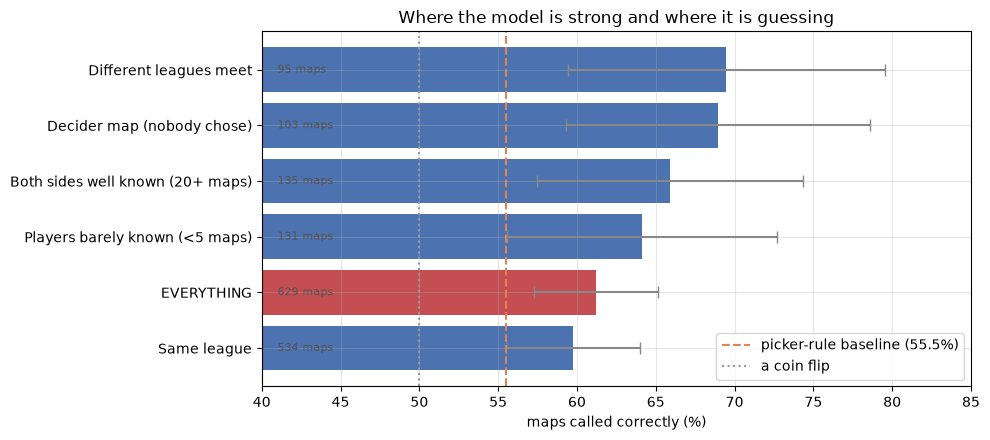

In [11]:
slices = {
    "Different leagues meet": checked["across_regions"] == "different leagues",
    "Decider map (nobody chose)": checked["map_picked_by"] == "decider",
    "Both sides well known (20+ maps)": checked["history"] >= 20,
    "EVERYTHING": pd.Series(True, index=checked.index),
    "Same league": checked["across_regions"] == "same league",
    "Players barely known (<5 maps)": checked["history"] < 5,
}

rows = [(name, checked.loc[mask, "right"].mean() * 100, int(mask.sum())) for name, mask in slices.items()]
chart = pd.DataFrame(rows, columns=["slice", "accuracy", "maps"]).sort_values("accuracy")

fig, ax = plt.subplots(figsize=(10, 4.5))
colours = ["#c44e52" if name == "EVERYTHING" else "#4c72b0" for name in chart["slice"]]
ax.barh(chart["slice"], chart["accuracy"], xerr=chart["maps"].map(noise),
        color=colours, ecolor="#888888", capsize=4)
ax.axvline(55.5, color="#dd8452", linestyle="--", label="picker-rule baseline (55.5%)")
ax.axvline(50, color="#999999", linestyle=":", label="a coin flip")
ax.set_xlim(40, 85)
ax.set_xlabel("maps called correctly (%)")
ax.set_title("Where the model is strong and where it is guessing")
for y, (accuracy, n) in enumerate(zip(chart["accuracy"], chart["maps"])):
    ax.text(41, y, f"{n} maps", va="center", fontsize=8, color="#555555")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. What this means

**The headline number hides two different situations.** The model is not uniformly a 61%
model. It is close to a coin flip when two evenly matched teams from the same league meet,
and genuinely useful — around 70% — when the two sides are far apart in strength.

That is the honest way to describe it, and a better line than any single percentage: **it
predicts mismatches well and toss-ups badly, which is what you would expect of something
that only knows how well the ten players have been performing.**

**What would help, in order:**

1. **Something that separates evenly matched teams.** That is where nearly all the errors
   are, and player ratings alone cannot do it. The hardest to get, and the most valuable.
2. **More history per player.** Both sides having 20+ rated maps is the model at its best
   outside of mismatches. A second season would let every player start the year with a
   record rather than a blank — though the combat-score repair has already taken the worst
   of the early-season penalty away.
3. Not more columns, and not a different kind of model. Notebooks 08 and 09 closed both.

**What would not help:** chasing the teams it reads worst. Section 7 shows it judges their
strength correctly and simply cannot call their individual maps.